In [1]:
%reset -f

In [2]:
import sys
sys.path.append(r"C:\ThesisWork\offical_approach\mth_project\mth_project\industrial_network_analysis")
from data_preprocessing import Dataset
from data_utils import remove_outliers

import warnings
import logging

warnings_logger = logging.getLogger('warnings')
warnings_logger.setLevel(logging.WARNING)
warning_handler = logging.FileHandler('warnings.log')
warning_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
warnings_logger.addHandler(warning_handler)

def warning_handler_func(message, category, filename, lineno, file=None, line=None):
    warnings_logger.warning(f"{category.__name__}: {message} (File: {filename}, Line: {lineno})")

warnings.showwarning = warning_handler_func

In [3]:
### READ DATA
device_name = "SW-SUPV-243"
df = Dataset(f'C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\industrial_network_analysis\\Data082025\\{device_name}.csv')

In [4]:
### search criteria

# names for STATUSES
statuses = ': operational status'
statuses_exclude = 'Unused'

# names for OTHER NUMERIC PARAMETERS
icmp_params = 'ICMP'
temperature = 'temperature'
cpu = 'cpu'

numeric_exclude = "status"

# names for traffic on ports - BITS SENT/RECEIVED
bits = "bits"
bits_exclude = "unused"

In [5]:
def get_column_names_exclude(df, search_keyword, exclude_keyword):
    df_column_names = df.get_column_names(search_keyword)
    df_column_names_excluded = []

    for col in df_column_names:
        if exclude_keyword.lower() not in col.lower():
            df_column_names_excluded.append(col)

    return df_column_names_excluded


df_column_all_names = get_column_names_exclude(df, statuses, statuses_exclude) + get_column_names_exclude(df, icmp_params, numeric_exclude) + get_column_names_exclude(df, temperature, numeric_exclude) + get_column_names_exclude(df, bits, bits_exclude)

df_columns_bits_names = get_column_names_exclude(df, bits, bits_exclude)
df_columns_other_numeric_names = get_column_names_exclude(df, icmp_params, numeric_exclude) + get_column_names_exclude(df, temperature, numeric_exclude) + get_column_names_exclude(df, cpu, numeric_exclude)
df_columns_statuses_names = get_column_names_exclude(df, statuses, statuses_exclude)

In [6]:
# all_columns = get_column_names_exclude(df, '', 'interface')

In [7]:
# test = df.get_column_values(all_columns)

In [8]:
# get values for defined names
df_bits = df.get_column_values(df_columns_bits_names)
df_other_numeric = df.get_column_values(df_columns_other_numeric_names)
df_statuses = df.get_column_values(df_columns_statuses_names)

In [9]:
# # change column names
df_bits.columns = df_bits.columns.str.replace('Interface Gi', '')
df_bits.columns = df_bits.columns.str.replace('Valmet SUPV switch connection', '')
df_bits.columns = df_bits.columns.str.replace('Supervisory access', '')
df_bits.columns = df_bits.columns.str.replace('Bits sent', 'out')
df_bits.columns = df_bits.columns.str.replace('Bits received', 'in')
df_bits.columns = df_bits.columns.str.replace('Valmet DNA', '')
df_other_numeric.columns = df_other_numeric.columns.str.replace('Interface Gi1/', '')
df_other_numeric.columns = df_other_numeric.columns.str.replace('Valmet DNA', '')
df_other_numeric.columns = df_other_numeric.columns.str.replace('HotSpot Temp Sensor', '')
df_statuses.columns = df_statuses.columns.str.replace('Interface Gi1/', '')
df_statuses.columns = df_statuses.columns.str.replace('Valmet DNA', '')

In [10]:
# remove nans
try:
    df_bits = remove_outliers(df_bits, 1).dropna()
except:
    print("Warning: remove_outliers failed for df_bits, using dropna only")
    df_bits = df_bits.dropna()

try:
    df_other_numeric = remove_outliers(df_other_numeric, 1).dropna()
except:
    print("Warning: remove_outliers failed for df_other_numeric, using dropna only")
    df_other_numeric = df_other_numeric.dropna()

try:
    df_statuses = remove_outliers(df_statuses, 1).dropna()
except:
    print("Warning: remove_outliers failed for df_statuses, using dropna only")
    df_statuses = df_statuses.dropna()

In [11]:
# description

bits_description = df_bits.describe()
other_numeric_description = df_other_numeric.describe()
statuses_description = df_statuses.describe()

In [12]:
import pandas as pd

# dynamics examination
df_bits_diff = df_bits.diff()
df_other_numeric_diff = df_other_numeric.diff()
df_statuses_diff = df_statuses.diff()

# calculate changes
df_bits_number_changes = (df_bits_diff != 0).sum()
df_other_numeric_number_changes = (df_other_numeric_diff != 0).sum()
df_statuses_number_changes = (df_statuses_diff != 0).sum()

#calculate percentage
df_bits_number_percent = df_bits_number_changes / df_bits_diff.shape[0] * 100
df_other_numeric_number_percent = df_other_numeric_number_changes / df_other_numeric_diff.shape[0] * 100
df_statuses_number_percent = df_statuses_number_changes / df_statuses_diff.shape[0] * 100

# cumulative results

df_bits_stats = pd.DataFrame({'calculate changes:': df_bits_number_changes, 'calculate percentage': df_bits_number_percent})
df_other_numeric_stats = pd.DataFrame({'calculate changes:': df_other_numeric_number_changes, 'calculate percentage': df_other_numeric_number_percent})
df_statuses_stats = pd.DataFrame({'calculate changes:': df_statuses_number_changes, 'calculate percentage': df_statuses_number_percent})


In [13]:
# export Series with results to csv file

# df_bits_stats.to_csv('C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\Results\\dynamics_examination_results\\df_bits.csv', index=True)
# df_other_numeric_stats.to_csv('C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\Results\\dynamics_examination_results\\df_other_numeric.csv', index=True)
# df_statuses_stats.to_csv('C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\Results\\dynamics_examination_results\\df_statuses.csv', index=True)

In [14]:
# save only columns where percentage of changes is above 2% (dynamic streams)
dynamic_bits = df_bits_stats[df_bits_stats['calculate percentage'] > 2]
dynamic_other_numeric = df_other_numeric_stats[df_other_numeric_stats['calculate percentage'] > 2]
dynamic_statuses = df_statuses_stats[df_statuses_stats['calculate percentage'] > 2]

dynamic_results = {
    'bits': dynamic_bits,
    'other_numeric': dynamic_other_numeric,
    'statuses': dynamic_statuses
}

In [15]:
# curve fitting - to examine seasonality and trend
from numpy import polyfit
import numpy as np

def fit(X, y, degree=3):
    coef = polyfit(X, y, degree)
    trendpoly = np.poly1d(coef)
    return trendpoly(X)
def get_season(s, yearly_periods=4, degree=3):
    X = [i%(365/4) for i in range(0, len(s))]
    seasonal = fit(X, s.values, degree)
    return pd.Series(data=seasonal, index=s.index)
def get_trend(s, degree=3):
    X = list(range(len(s)))
    trend = fit(X, s.values, degree)
    return pd.Series(data=trend, index=s.index)

In [16]:
# copy only dynamic values to new variables
dynamic_bits_values = df_bits[dynamic_bits.index]
dynamic_other_numeric_values = df_other_numeric[dynamic_other_numeric.index]
dynamic_statuses_values = df_statuses[dynamic_statuses.index]

# add them to one cumulative DataFrame
dynamic_cumulative = pd.concat([dynamic_bits_values, dynamic_other_numeric_values, dynamic_statuses_values], axis=1)
cumulative = pd.concat([df_bits, df_other_numeric, df_statuses])
dynamic_cumulative = dynamic_cumulative.dropna()

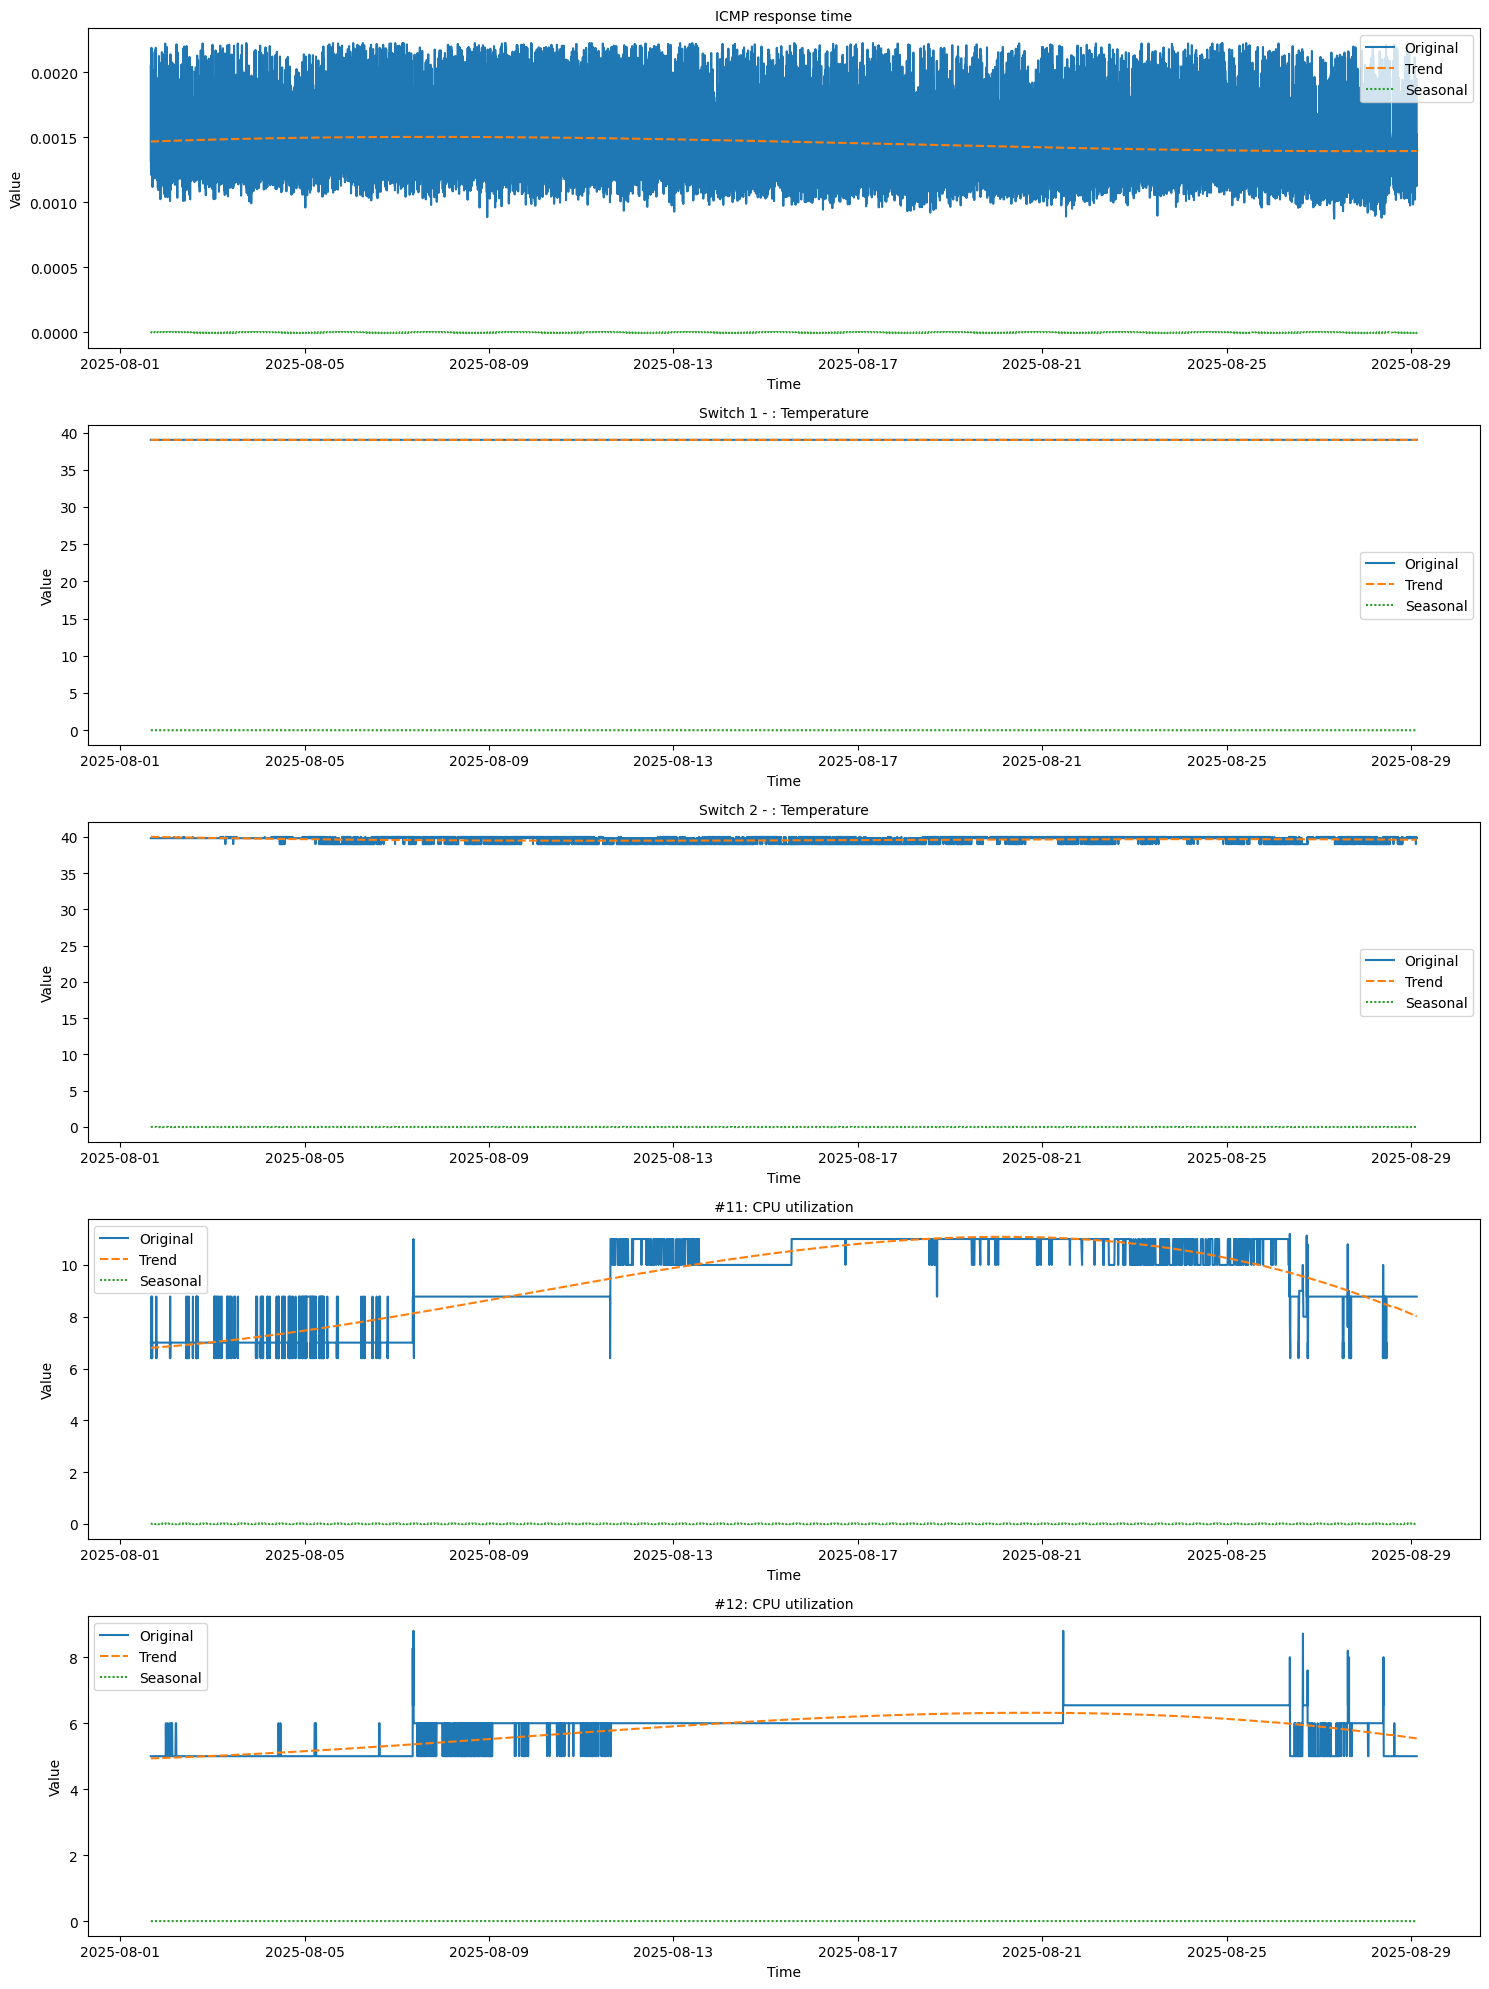

In [17]:
# seasonality and trend for other numeric values

import seaborn as sns
import matplotlib.pyplot as plt
import math

# 24 first hours
time = 24 * 60
#dynamic_other_numeric_values_limited = dynamic_other_numeric_values.iloc[:time]
dynamic_other_numeric_values_limited = dynamic_other_numeric_values

num_cols = len(dynamic_other_numeric_values_limited.columns)
cols = 1  # Number of columns in the grid
rows = math.ceil(num_cols / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
axes = axes.flatten() if num_cols > 1 else [axes]

for i, col in enumerate(dynamic_other_numeric_values_limited.columns):
    # Calculate trend and seasonal components
    trend = get_trend(dynamic_other_numeric_values_limited[col])
    seasonal = get_season(dynamic_other_numeric_values_limited[col] - trend)

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        'Original': dynamic_other_numeric_values_limited[col],
        'Trend': trend,
        'Seasonal': seasonal
    })
    
    # Plot all components
    sns.lineplot(data=plot_data, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Value')
    axes[i].legend()

# Remove empty subplots
for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

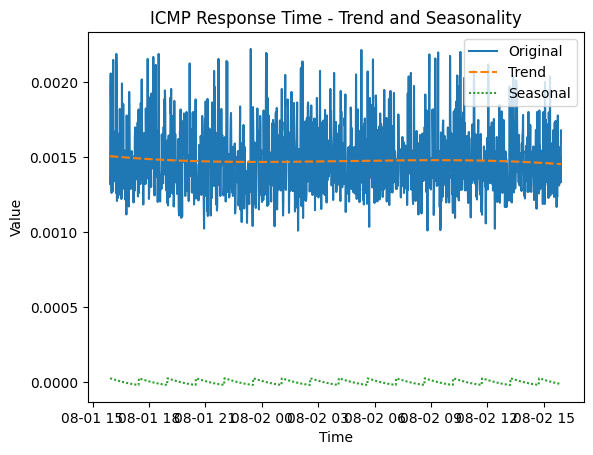

In [18]:
# example of seasonality and trend for icmp response time

icmp_response_time = dynamic_other_numeric_values_limited['ICMP response time'][:24*60]

icmp_trend = get_trend(icmp_response_time)
icmp_seasonal = get_season(icmp_response_time - icmp_trend)

icmp_plot_data = pd.DataFrame({
    'Original': icmp_response_time,
    'Trend': icmp_trend,
    'Seasonal': icmp_seasonal
})

sns.lineplot(data=icmp_plot_data)
plt.title('ICMP Response Time - Trend and Seasonality')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

Dickey-Fuller test for stationarity and export result to excel adf_results.xlsx

In [19]:
# # Dickey-Fuller test for stationarity

# from statsmodels.tsa.stattools import adfuller

# adf_results = {}
# for col in cumulative.columns:
#     series = cumulative[col].dropna()
#     result = adfuller(series)
#     adf_results[col] = {
#         'ADF Statistic': result[0],
#         'p-value': result[1],
#         'Critical Values': result[4]
#     }

# for col, res in adf_results.items():
#     print(f"{col}:")
#     print(f"  ADF Statistic: {res['ADF Statistic']:.4f}")
#     print(f"  p-value: {res['p-value']:.4g}")
#     print(f"  Critical Values: {res['Critical Values']}")
#     print()

In [20]:
# import pandas as pd

# def create_adf_results_table(adf_results):
#     """Convert ADF test results to a formatted DataFrame table"""
#     table_data = []
    
#     for col, res in adf_results.items():
#         # Determine stationarity based on p-value
#         is_stationary = "Yes" if res['p-value'] < 0.05 else "No"
        
#         # Check which critical value thresholds are met
#         adf_stat = res['ADF Statistic']
#         cv_1 = res['Critical Values']['1%']
#         cv_5 = res['Critical Values']['5%']
#         cv_10 = res['Critical Values']['10%']
        
#         if adf_stat < cv_1:
#             significance = "1%"
#         elif adf_stat < cv_5:
#             significance = "5%"
#         elif adf_stat < cv_10:
#             significance = "10%"
#         else:
#             significance = "None"
        
#         table_data.append({
#             'Variable': col,
#             'ADF Statistic': f"{adf_stat:.4f}",
#             'p-value': f"{res['p-value']:.2e}" if res['p-value'] > 0 else "0.0000",
#             'Critical Value 1%': f"{cv_1:.4f}",
#             'Critical Value 5%': f"{cv_5:.4f}",
#             'Critical Value 10%': f"{cv_10:.4f}",
#             'Stationary (p<0.05)': is_stationary,
#             'Significance Level': significance
#         })
    
#     return pd.DataFrame(table_data)

# # Create the table
# adf_table = create_adf_results_table(adf_results)

# # Display the table
# print("Augmented Dickey-Fuller Test Results")
# print("=" * 80)
# print(adf_table.to_string(index=False))

# # Export to CSV if needed
# # adf_table.to_csv('adf_test_results.csv', index=False)

# def display_adf_summary_table(adf_results):
#     """Create a simplified summary table"""
#     summary_data = []
    
#     for col, res in adf_results.items():
#         is_stationary = "✓" if res['p-value'] < 0.05 else "✗"
#         p_val_str = "< 0.001" if res['p-value'] < 0.001 else f"{res['p-value']:.4f}"
        
#         summary_data.append({
#             'Variable': col,
#             'ADF Statistic': f"{res['ADF Statistic']:.4f}",
#             'p-value': p_val_str,
#             'Stationary': is_stationary,
#             'Interpretation': "Stationary" if res['p-value'] < 0.05 else "Non-stationary"
#         })
    
#     summary_df = pd.DataFrame(summary_data)
    
#     print("\nADF Test Summary")
#     print("=" * 60)
#     print(summary_df.to_string(index=False))
    
#     # Count stationary vs non-stationary
#     stationary_count = sum(1 for res in adf_results.values() if res['p-value'] < 0.05)
#     total_count = len(adf_results)
    
#     print(f"\nSummary: {stationary_count}/{total_count} variables are stationary (p < 0.05)")
    
#     return summary_df

# # Create summary table
# adf_summary = display_adf_summary_table(adf_results)

# def export_adf_to_excel(adf_results, filename='adf_results.xlsx'):
#     """Export ADF results to Excel with formatting"""
#     import pandas as pd
    
#     # Create detailed table
#     detailed_table = create_adf_results_table(adf_results)
    
#     # Create summary table
#     summary_table = display_adf_summary_table(adf_results)
    
#     # Export to Excel with multiple sheets
#     with pd.ExcelWriter(filename, engine='openpyxl') as writer:
#         detailed_table.to_excel(writer, sheet_name='Detailed Results', index=False)
#         summary_table.to_excel(writer, sheet_name='Summary', index=False)
    
#     print(f"Results exported to {filename}")

# # Export results
# export_adf_to_excel(adf_results)

Cross-corelation tests for following cases:
1. other numeric values
2. traffic on ports and other numeric values
3. sum of received and sent traffic on ports and other numeric values
4. 

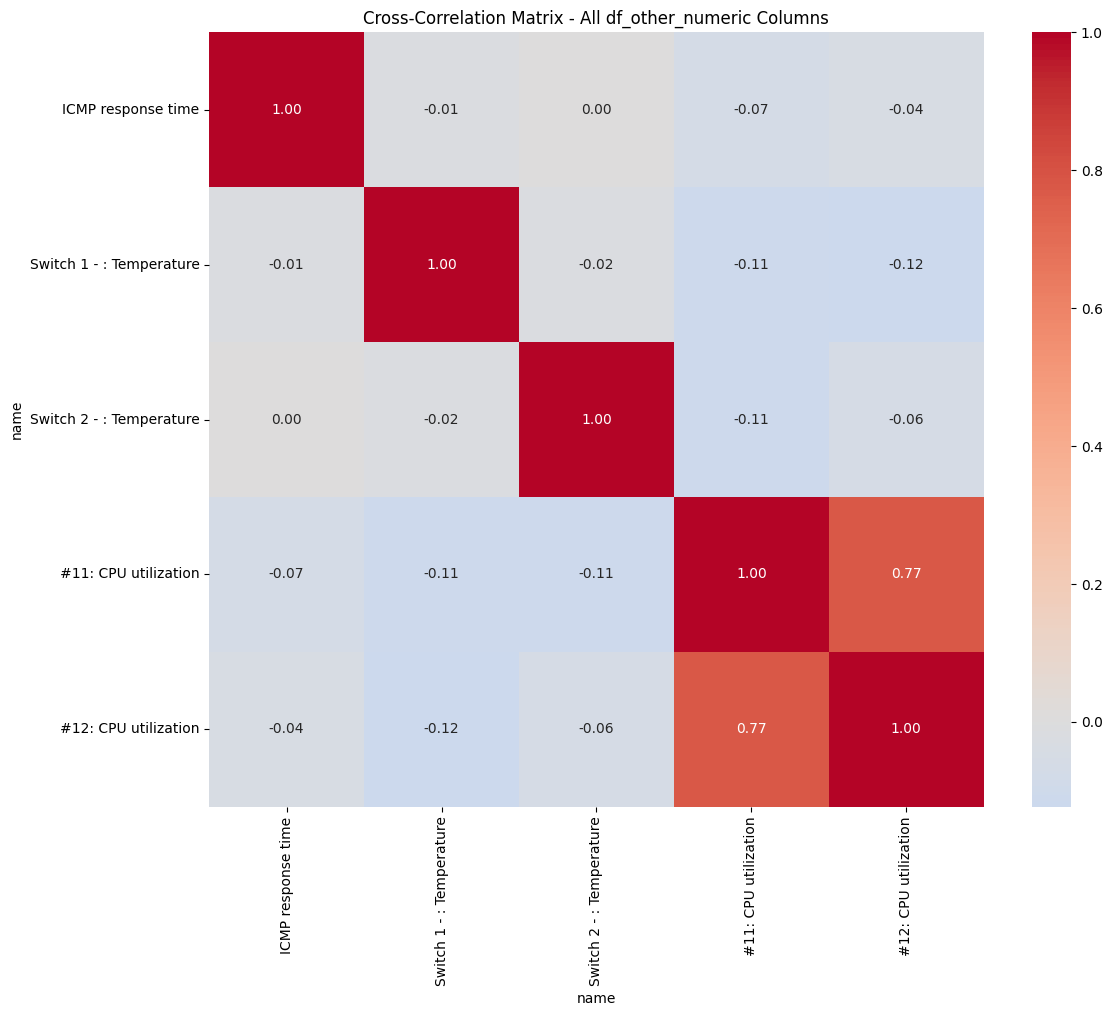

In [21]:
# cross-correlation for other numeric values

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlation matrix
correlation_matrix = dynamic_other_numeric_values_limited.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Cross-Correlation Matrix - All df_other_numeric Columns')
plt.tight_layout()
plt.show()

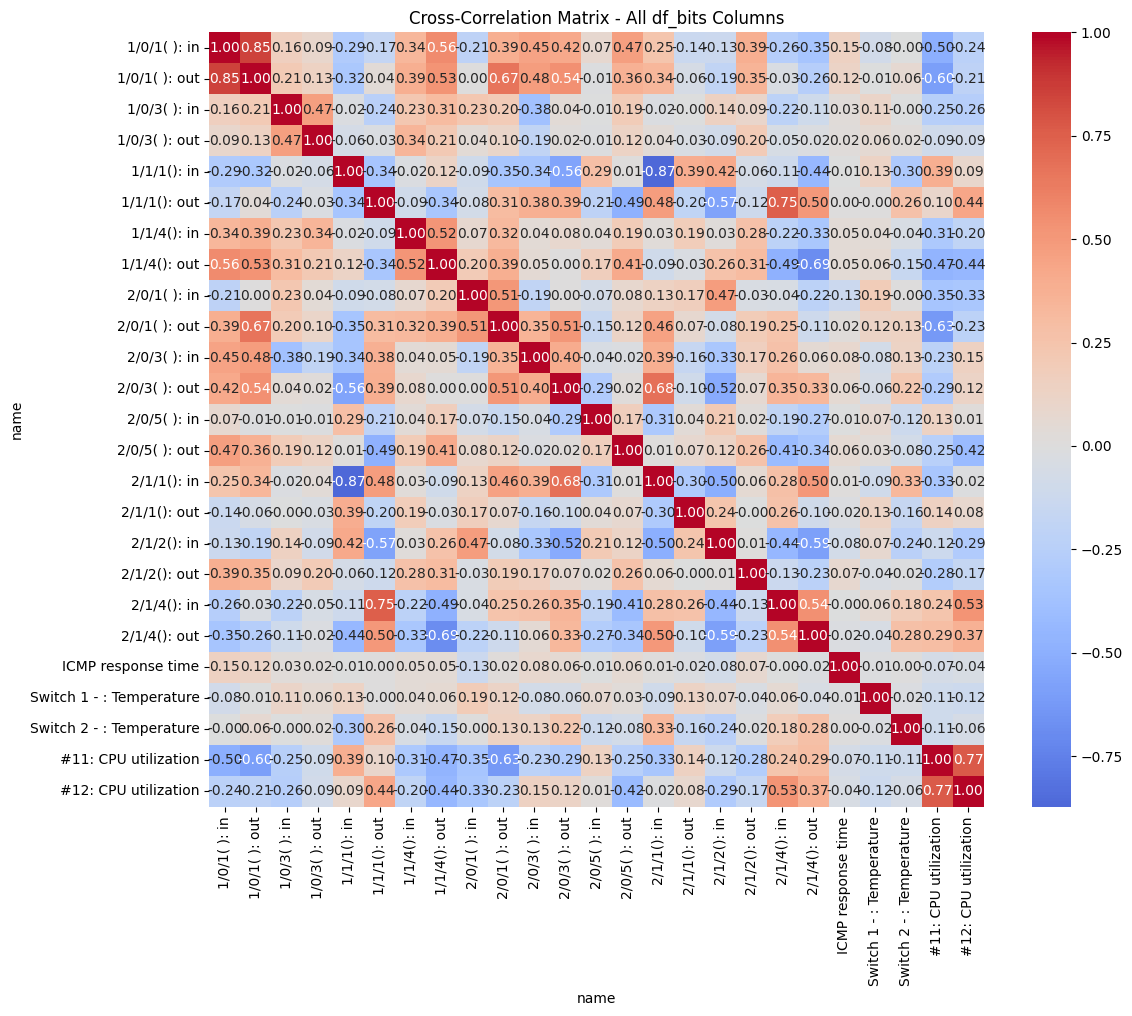

In [22]:
# cross-correlation between all ports and other numeric values
dynamic_bits_plus_dynamic_other_numeric = pd.concat([dynamic_bits_values, dynamic_other_numeric_values], axis=1)

# cross-correlation between all ports and other numeric values
correlation_matrix = dynamic_bits_plus_dynamic_other_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Cross-Correlation Matrix - All df_bits Columns')
plt.tight_layout()
plt.show()

In [23]:
# sum of bits received and sent
sum_bits_received = dynamic_bits_values.filter(like='in').sum(axis=1)
sum_bits_sent = dynamic_bits_values.filter(like='out').sum(axis=1)

sum_bits_df = pd.DataFrame({
    'sum_bits_received': sum_bits_received,
    'sum_bits_sent': sum_bits_sent})

# connect summed bits with other numeric values
sum_bits_df_other_numeric_values = pd.concat([sum_bits_df, dynamic_other_numeric_values], axis=1)

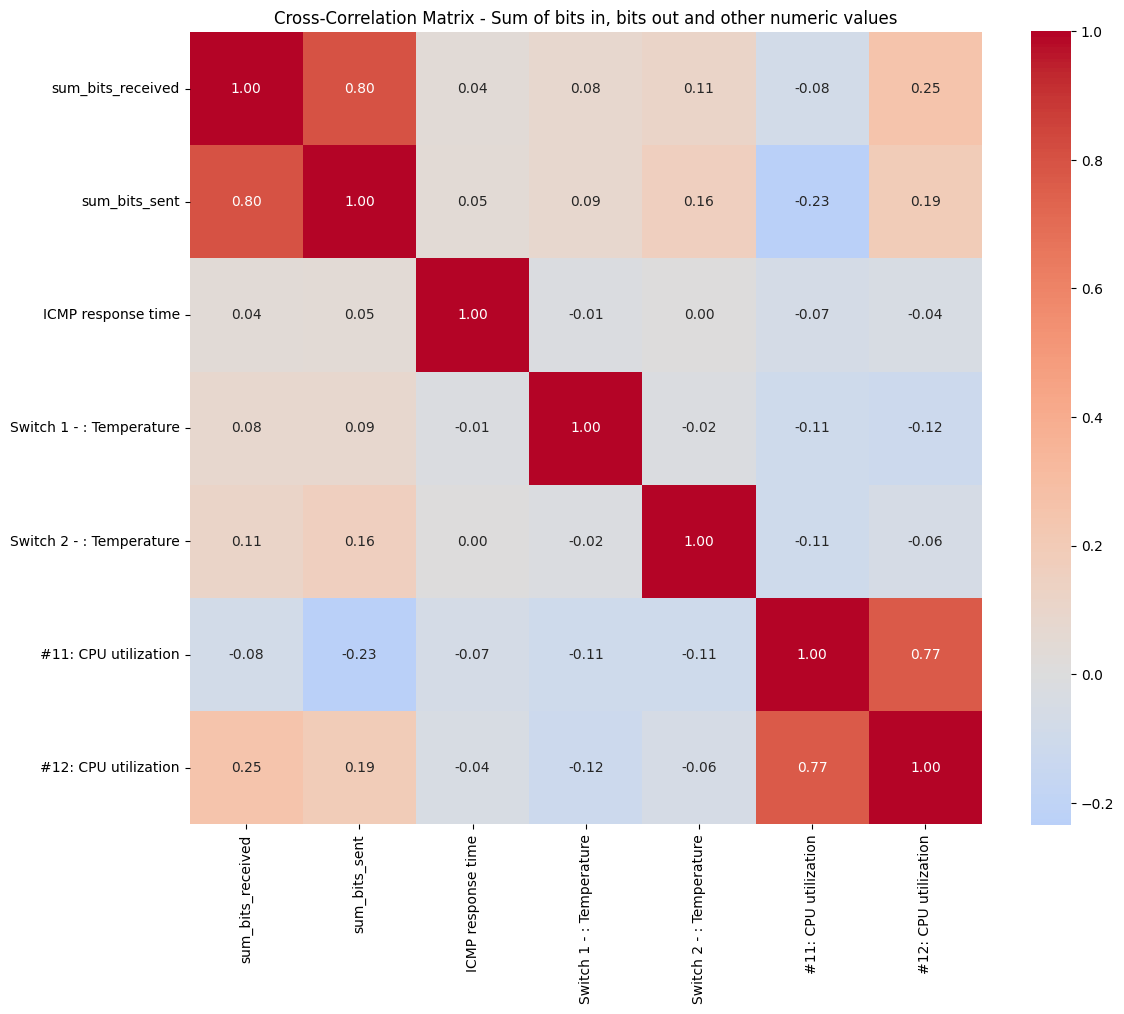

In [24]:
# cross-correlation between sum of received bits, sent bits and other numeric values
correlation_matrix = sum_bits_df_other_numeric_values.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Cross-Correlation Matrix - Sum of bits in, bits out and other numeric values')
plt.tight_layout()
plt.show()